In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [20]:
INPUT_PATH = '/content/drive/MyDrive/y3s2/SRIP/csvs from posthog'
OUTPUT_PATH = '/content/drive/MyDrive/y3s2/SRIP/data'

#### The CSV files used are from Posthog views:

| Posthog view | CSV file | Description |
| -------- | -------- | -------- |
| events_with_study_sessions | Cohort2510.csv | All events from the 2510 cohort, with reconstructed study sessions |
| assignment_due_dates | AssignmentDueDates.csv | All course assignment due dates (earliest) |
| students_name_id | Students.csv | All students with name + ID (distinct_id) |


In [321]:
df = pd.read_csv(os.path.join(INPUT_PATH, 'Cohort2510.csv'))
assignments_df = pd.read_csv(os.path.join(INPUT_PATH, 'AssignmentDueDates.csv'))
students_df = pd.read_csv(os.path.join(INPUT_PATH, 'Students.csv'))

In [258]:
## Load saved parquets
df = pd.read_parquet(os.path.join(OUTPUT_PATH, 'Cohort2510_with_features.parquet'))
assignments_df = pd.read_parquet(os.path.join(INPUT_PATH, 'assignments.parquet'))
weekly_activity = pd.read_parquet(os.path.join(OUTPUT_PATH, 'weekly_activity.parquet'))

## Adding features to df

Some features would take too long to include in Posthog's SQL editor. As such, they will be included in this notebook using Python.

### 1. Academic calendar weeks (`course_week`)
- Weeks are according to NUS AY25/26
- According to the timestamp column in df, add the corresponding `course_week`
- Enables grouping events by actual timelines that the course follows, instead of arbitrary calendar weeks

In [322]:
acad_calendar = [
    ('week_1',       '2026-01-12', '2026-01-18'),     ## original (nus) does not include weekends
    ('week_2',       '2026-01-19', '2026-01-25'),
    ('week_3',       '2026-01-26', '2026-02-01'),
    ('week_4',       '2026-02-02', '2026-02-08'),
    ('week_5',       '2026-02-09', '2026-02-15'),
    ('week_6',       '2026-02-16', '2026-02-22'),
    ('recess',       '2026-02-23', '2026-03-01'),
    ('week_7',       '2026-03-02', '2026-03-08'),
    ('week_8',       '2026-03-09', '2026-03-15'),
    ('week_9',       '2026-03-16', '2026-03-22'),
    ('week_10',      '2026-03-23', '2026-03-29'),
    ('week_11',      '2026-03-30', '2026-04-05'),
    ('week_12',      '2026-04-06', '2026-04-12'),
    ('week_13',      '2026-04-13', '2026-04-19'),
    ('reading',      '2026-04-20', '2026-04-24'),
    ('exam_1',       '2026-04-25', '2026-05-03'),
    ('exam_2',       '2026-05-04', '2026-05-09'),
]
cal_df = pd.DataFrame(acad_calendar, columns=['course_week', 'start', 'end'])
cal_df['start'] = pd.to_datetime(cal_df['start'])
cal_df['end'] = pd.to_datetime(cal_df['end'])

## Add course_week to df
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True).dt.tz_localize(None)
df['date'] = df['timestamp'].dt.normalize()

df = pd.merge_asof(
    df, cal_df[['start', 'course_week']].rename(columns={'start': 'date'}),
    on='date',
    direction='backward',
)


In [323]:
print(df['course_week'].value_counts())  ## Number of events that took place in each week

week_order = ['week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'recess', 'week_7', 'week_8', 'week_9', 'week_10', 'week_11', 'week_12', 'week_13', 'reading', 'exam_1', 'exam_2']
df['course_week'] = pd.Categorical(df['course_week'], week_order)

course_week
week_12    5172
week_11    4004
week_5     3694
week_9     3228
week_2     2688
week_1     2583
week_4     2423
week_13    2340
week_6     2321
week_3     2006
week_7     1940
week_10    1871
reading    1776
recess     1542
week_8     1313
exam_1       65
exam_2       32
Name: count, dtype: int64


### 2. `days_to_exercise` && `days_to_paper`
- `days_to_exercise`: The number of days left to an exercise's due date, from the event creation timestamp
- `days_to_paper`: The number of days left to a paper's due date, from the event creation timestamp

- Enables analysis of how different students' activity/behaviour patterns change as deadlines approach (e.g. last-minute cramming, sustained engagement throughout, drop offs after submission)

In [324]:
def classify(name):
    n = name.lower()
    if n.startswith('paper'):
        return 'paper'
    if n.startswith('ex'):
        return 'exercise'
    return 'other'

In [325]:
assignments_df['assignment_type'] = assignments_df['assignment'].apply(classify)
assignments_df['due_date'] = pd.to_datetime(assignments_df['due_date'])

exercise_due_dates = assignments_df.loc[assignments_df['assignment_type'] == 'exercise', 'due_date'].sort_values().reset_index(drop=True)
paper_due_dates = assignments_df.loc[assignments_df['assignment_type'] == 'paper', 'due_date'].sort_values().reset_index(drop=True)

## Find days until the NEXT CLOSEST exercise / paper due date
df['timestamp_date'] = df['timestamp'].dt.normalize()
df = df.sort_values('timestamp_date').reset_index(drop=True)

ex_lookup = (
    assignments_df[assignments_df['assignment_type'] == 'exercise'][['due_date', 'assignment']]
    .sort_values(by='due_date')
    .rename(columns={'due_date': 'next_exercise_due', 'assignment': 'next_exercise'})
    .reset_index(drop=True)
)
paper_lookup = (
    assignments_df[assignments_df['assignment_type'] == 'paper'][['due_date', 'assignment']]
    .sort_values(by='due_date')
    .rename(columns={'due_date': 'next_paper_due', 'assignment': 'next_paper'})
    .reset_index(drop=True)
)

## For each timestamp_date, find the closest due_date that >= event_date
## Note: This does not account for overdue assignments
df = pd.merge_asof(
    df, ex_lookup,
    left_on='timestamp_date', right_on='next_exercise_due',
    direction='forward',
)
df = pd.merge_asof(
    df, paper_lookup,
    left_on='timestamp_date', right_on='next_paper_due',
    direction='forward',
)

df['days_to_exercise_due'] = (df['next_exercise_due'] - df['timestamp_date']).dt.days
df['days_to_paper_due'] = (df['next_paper_due'] - df['timestamp_date']).dt.days


#### Save assignments_df with added features to parquet


In [343]:
assignments_df.to_parquet(os.path.join(OUTPUT_PATH, 'assignments.parquet'))

### 3. Add student names (`student_name`)
- Match student names from `students_df` to events based on `distinct_id`

In [326]:
df = pd.merge(df, students_df, on='distinct_id', how='left')
df.head()

,os,link,page,text,event,device,browser,duration,pathname,timestamp,...,date,course_week,timestamp_date,next_exercise_due,next_exercise,next_paper_due,next_paper,days_to_exercise_due,days_to_paper_due,name
0,Windows,NaN,NaN,NaN,$pageview,NaN,Chrome,NaN,/,2026-01-12 07:43:13.594,...,2026-01-12,week_1,2026-01-12,2026-01-13,ex1,2026-02-08,paper1-prewriting-ungraded,1.0,27.0,JoshuaSimJunHui
1,Mac OS X,NaN,NaN,NaN,$pageleave,NaN,Chrome,NaN,/course-ntw2029/assignments/exercises/e01-intr...,2026-01-12 13:23:07.233,...,2026-01-12,week_1,2026-01-12,2026-01-13,ex1,2026-02-08,paper1-prewriting-ungraded,1.0,27.0,LeeJaeYan
2,Mac OS X,https://ntw-2029.vercel.app/course-ntw2029/sch...,NaN,3.2 Thu 29 Jan 2026,internalLinkClick,NaN,Chrome,NaN,/course-ntw2029/schedule,2026-01-12 13:23:08.785,...,2026-01-12,week_1,2026-01-12,2026-01-13,ex1,2026-02-08,paper1-prewriting-ungraded,1.0,27.0,LeeJaeYan
3,Mac OS X,NaN,NaN,NaN,$autocapture,NaN,Chrome,NaN,/course-ntw2029/schedule,2026-01-12 13:23:08.785,...,2026-01-12,week_1,2026-01-12,2026-01-13,ex1,2026-02-08,paper1-prewriting-ungraded,1.0,27.0,LeeJaeYan
4,Mac OS X,NaN,NaN,NaN,$autocapture,NaN,Chrome,NaN,/course-ntw2029/schedule,2026-01-12 13:23:11.374,...,2026-01-12,week_1,2026-01-12,2026-01-13,ex1,2026-02-08,paper1-prewriting-ungraded,1.0,27.0,LeeJaeYan


In [327]:
print(df['distinct_id'].value_counts())
print(df['name'].value_counts())

distinct_id
40    3046
42    2794
31    2643
33    2637
35    2627
49    2622
38    2332
46    2183
48    2155
44    2150
26    1848
39    1755
29    1573
47    1558
50    1351
32    1292
34    1249
30     975
37     818
28     704
41     271
43     214
45     163
36      38
Name: count, dtype: int64
name
KimYongchan               3046
LeeJaeYan                 2794
ChiaChengXuXavier         2643
DishaShivaraman           2637
GuoRuiTing                2627
SeetohYihKeet             2622
JoshuaSimJunHui           2332
NgYeeXiang                2183
SatapathyPulastya         2155
LinBo-Ruei                2150
AshleyGohYuTing           1848
KimAmin                   1755
BennettHoChengXun         1573
RenZhaoyi                 1558
YeohKhangSian             1351
ChowdhuryTia              1292
EthanDhirenDivyanathan    1249
ChanEugene                 975
IanTayQiShen               818
BansalNaman                704
KongXinYang                271
LimJingYuan                214
MarcusWeeYu

### 4. Checking for NA values

In [328]:
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f"{col}: {df[col].isna().sum()} NA values")

link: 33994 NA values
page: 33015 NA values
text: 29569 NA values
device: 35917 NA values
duration: 37258 NA values
secs_since_prev_event_in_session: 3029 NA values
next_exercise_due: 1498 NA values
next_exercise: 1498 NA values
next_paper_due: 1873 NA values
next_paper: 1873 NA values
days_to_exercise_due: 1498 NA values
days_to_paper_due: 1873 NA values


#### 4.1. Check if expected == actual number of NA values (fields related to custom events)
- Some fields are only available in certain custom events, hence
NA values in those fields == (Total values - total number of those custom events)
- Result: Number of NA values in `link`, `page`, `text` & `duration` are expected

In [329]:
## link: internalLinkClick, externalLinkClick
link_customs = ['internalLinkClick', 'externalLinkClick']
link_events_sum = len(df[~df['event'].isin(link_customs)])
print(f'Total number of non-link_customs/externalLinkClick events: {link_events_sum}')

## page: read, openNutshell, openQuiz, closeQuiz
page_customs = ['read', 'openNutshell', 'openQuiz', 'closeQuiz']
page_events_sum = len(df[~df['event'].isin(page_customs)])
print(f'Total number of non-page_customs events: {page_events_sum}')

## text: openNutshell, inactiveNutshell, internalLinkClick, externalLinkClick , openQuiz, 'closeQuiz'
text_customs = ['openNutshell', 'inactiveNutshell', 'internalLinkClick', 'externalLinkClick', 'openQuiz', 'closeQuiz']
text_events_sum = len(df[~df['event'].isin(text_customs)])
print(f'Total number of non-text_customs events: {text_events_sum}')

## duration: inactiveNutshell, 'closeQuiz'
dur_customs = ['inactiveNutshell', 'closeQuiz']
dur_events_sum = len(df[~df['event'].isin(dur_customs)])
print(f'Total number of non-dur_customs events: {dur_events_sum}')


Total number of non-link_customs/externalLinkClick events: 33994
Total number of non-page_customs events: 33015
Total number of non-text_customs events: 29569
Total number of non-dur_customs events: 37258


#### 4.2. Check if expected == actual number of NA values (for default events)
**4.2.1.** `device` : Should only have values if student is using a mobile. NA values cannot be verified here, as it is not possible to verify if student is using a laptop.
- Expected NA instances will be kept as NA.

**4.2.2.** `secs_since_prev_event_in_session` : Should be NA if current event is the first event in the session. Can be verified using the `is_new_session` flag.  
- Expected NA instances will be kept as NA.

**4.2.3.** `next_exercise_due`, `next_paper_due`, `days_to_exercise_due`, `days_to_paper_due` : Computed based on the earliest assignment due date.
  - As such, events that occurred between the earliest & latest due dates would be expected to have NA values.
  - Fix: Manual patching of NA values for events that fall into this category --> NA values will be recomputed using latest due date.
    - **Limitation**: Patched events are assumed to belong to students with the later deadline. However, without per-student deadline information, it is not possible to distinguish if these events belong to students with the earlier deadline (overdue), or if the later deadline assumption holds.

    - Remaining NA values are expected to be from events with timestamp > latest due date --> will be kept as NA.
  - Last exercise: 2026-04-20 - 2026-04-23
  - Last paper: 2026-04-19 - 2026-04-22

**4.2.2.** `secs_since_prev_event_in_session`

In [330]:
len(df[df['is_new_session'] == 1])  ## Expected: 3029

3029

**4.2.3.** `next_exercise_due`, `next_paper_due`, `days_to_exercise_due`, `days_to_paper_due`

In [331]:
assignments_df.sort_values(by='due_date')

,assignment,due_date,assignment_type
0,ex1,2026-01-13,exercise
1,ex2,2026-01-18,exercise
2,ex3,2026-01-25,exercise
3,ex4,2026-02-01,exercise
4,ex13,2026-02-01,exercise
5,paper1-prewriting-ungraded,2026-02-08,paper
6,paper1-draft-ungraded,2026-02-15,paper
7,ex5,2026-02-19,exercise
8,paper1-final-ungraded,2026-02-19,paper
9,ex6,2026-02-20,exercise


In [332]:
## VERIFYING
## Last exercise
LAST_EXERCISE = pd.Timestamp('2026-04-23')
print(f'Number of events with timestamp > latest due date of last exercise: {len(df[df['timestamp'] > LAST_EXERCISE])}')

## Last paper
LAST_PAPER = pd.Timestamp('2026-04-22')
print(f'Number of events with timestamp > latest due date of last paper: {len(df[df['timestamp'] > LAST_PAPER])}\n')

## Date ranges of events with timestamps that are before latest due dates
df_ex = df[(df['next_exercise_due'].isna()) & (df['timestamp'] <= LAST_EXERCISE)]
print(f'Date range (exercises): {df_ex['timestamp'].min()} --> {df_ex['timestamp'].max()}')
print(f'Number of events that fall within this date range: {len(df_ex)}\n')
df_pa = df[(df['next_paper_due'].isna()) & (df['timestamp'] <= LAST_PAPER)]
print(f'Date range (papers): {df_pa['timestamp'].min()} --> {df_pa['timestamp'].max()}')
print(f'Number of events that fall within this date range: {len(df_pa)}\n')

## Expected total NA values for exercise & paper fields
print(f'Total expected NAs (exercise): {len(df[df['timestamp'] > LAST_EXERCISE]) + len(df_ex)}')
print(f'Total expected NAs (paper): {len(df[df['timestamp'] > LAST_PAPER]) + len(df_pa)}')

Number of events with timestamp > latest due date of last exercise: 662
Number of events with timestamp > latest due date of last paper: 1075

Date range (exercises): 2026-04-21 01:02:54.869000 --> 2026-04-22 23:48:49.866000
Number of events that fall within this date range: 836

Date range (papers): 2026-04-20 01:03:02.673000 --> 2026-04-21 22:07:04.431000
Number of events that fall within this date range: 798

Total expected NAs (exercise): 1498
Total expected NAs (paper): 1873


In [333]:
## PATCHING
## Flag which rows are being patched (for transparency)
df['exercise_due_imputed'] = (
    df['next_exercise_due'].isna() & (df['timestamp'] <= LAST_EXERCISE)
)
df['paper_due_imputed'] = (
    df['next_paper_due'].isna() & (df['timestamp'] <= LAST_PAPER)
)

## Fill the ambiguous-window NAs using latest exercise/paper deadlines
df.loc[df['exercise_due_imputed'], 'next_exercise_due'] = LAST_EXERCISE
df.loc[df['exercise_due_imputed'], 'days_to_exercise_due'] = (
    LAST_EXERCISE - df.loc[df['exercise_due_imputed'], 'timestamp']
).dt.days

df.loc[df['paper_due_imputed'], 'next_paper_due'] = LAST_PAPER
df.loc[df['paper_due_imputed'], 'days_to_paper_due'] = (
    LAST_PAPER - df.loc[df['paper_due_imputed'], 'timestamp']
).dt.days

## Verifying post-patching #s
print(f"""Exercise NAs after patch:
      `next_exercise_due`: {df["next_exercise_due"].isna().sum()}
      `days_to_exercise_due`: {df["days_to_exercise_due"].isna().sum()}\n""")  ## expected 662
print(f"""Paper NAs after patch:
      `next_paper_due`: {df["next_paper_due"].isna().sum()}
      `days_to_paper_due`: {df["days_to_paper_due"].isna().sum()}\n""") ## expected 1075
print(f'Exercise rows imputed: {df["exercise_due_imputed"].sum()}') ## expected 836
print(f'Paper rows imputed: {df["paper_due_imputed"].sum()}') ## expected 798

Exercise NAs after patch: 
      `next_exercise_due`: 662  
      `days_to_exercise_due`: 662

Paper NAs after patch: 
      `next_paper_due`: 1075  
      `days_to_paper_due`: 1075

Exercise rows imputed: 836
Paper rows imputed: 798


In [334]:
df.shape

(38998, 35)

### Save df with added features to parquet


In [335]:
df.to_parquet(os.path.join(OUTPUT_PATH, 'Cohort2510_with_features.parquet'))

In [336]:
## Extract to csv
df.to_csv(os.path.join(OUTPUT_PATH, 'Cohort2510_with_features.csv'), index=False)

## Create `weekly_activity` dataframe
- A per-student per-week aggregation of all events in the Cohort2510.csv
- Each student has a row for each academic week (`course_week`), with the fields:
| Field | Description |
| -------- | -------- |
| weekly_session_count | Number of study sessions in the week |
| avg_weekly_duration | Average duration of all study sessions in a week |
| prev_week_sessions | Previous week's number of study sessions |
| prev_week_duration | Previous week's average duration of study sessions |
| 3wk_avg_sessions | Average count of study sessions in the previous 3 weeks |
| 3wk_avg_duration | Average duration across study sessions in the previous 3 weeks  |

- Enables week-by-week comparisons of student engagement + makes visualizing unusual dips or spikes in activity across weeks/students easier

#### Limitations:

- **Study sessions are reconstructed:** Study sessions are inferred from gaps between event timestamps, not  reported by students. As such, a study session may not actually reflect a continuous period of study, from the student's perspective.

- **Duration may overestimate engagement:** The duration of a study session is treated as time spent studying, but students may have switched to other tabs/walked away from their laptop/left the page open while doing something else. (mitigated by tabFocused/tabUnfocused events)

- **No actual signal on whether students were actually engaging:** Session counts and durations only provide rough ideas of which materials students opened.


In [337]:
## For each student:
## 1. Get session count & average session duration over each week
weekly_activity = (
    df.groupby(['distinct_id', 'course_week'])
      .agg(
          weekly_session_count=('study_session_id', 'nunique'),
          avg_weekly_duration=('study_session_duration', 'mean')
      )
      .reset_index()
)
weekly_activity = weekly_activity.sort_values(['distinct_id', 'course_week'])
grouped_wa = weekly_activity.groupby('distinct_id', group_keys=False)
## Some session_count and avg_weekly_duration values are 0 --> dividing to get avg will == NA
weekly_activity['avg_weekly_duration'] = weekly_activity['avg_weekly_duration'].fillna(0)

## 2. Add student names to weekly activity
name_lookup = df.dropna(subset=['name']).groupby('distinct_id')['name'].first()
weekly_activity['name'] = weekly_activity['distinct_id'].map(name_lookup)

## 3. Get previous week's session count & avg session duration
weekly_activity['prev_week_sessions'] = grouped_wa['weekly_session_count'].shift(1)
weekly_activity['prev_week_duration'] = grouped_wa['avg_weekly_duration'].shift(1)

## 4. Get average of past 3 week's session count & avg session duration
weekly_activity['3wk_avg_sessions'] = (
    grouped_wa['weekly_session_count']
    .apply(lambda x: x.shift(1).rolling(window=3).mean())
    .reset_index(drop=True)
)
weekly_activity['3wk_avg_duration'] = (
    grouped_wa['avg_weekly_duration']
    .apply(lambda x: x.shift(1).rolling(window=3).mean())
    .reset_index(drop=True)
)

/tmp/ipykernel_8691/1963992201.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['distinct_id', 'course_week'])


In [338]:
print(weekly_activity.shape)
weekly_activity.head()

(408, 9)


,distinct_id,course_week,weekly_session_count,avg_weekly_duration,name,prev_week_sessions,prev_week_duration,3wk_avg_sessions,3wk_avg_duration
0,26,week_1,17,805.686667,AshleyGohYuTing,NaN,NaN,NaN,NaN
1,26,week_2,8,1229.037736,AshleyGohYuTing,17.0,805.686667,NaN,NaN
2,26,week_3,4,20.833333,AshleyGohYuTing,8.0,1229.037736,NaN,NaN
3,26,week_4,5,660.863158,AshleyGohYuTing,4.0,20.833333,9.666667,685.185912
4,26,week_5,7,1599.317073,AshleyGohYuTing,5.0,660.863158,5.666667,636.911409


In [339]:
## Expected:
## - prev_week_* : 24 NA values
## - 3wk_avg_* : 24 students * 3 weeks = 72 NA values
for col in weekly_activity.columns:
    if weekly_activity[col].isna().sum() > 0:
        print(f'{col}: {weekly_activity[col].isna().sum()} NA values')

prev_week_sessions: 24 NA values
prev_week_duration: 24 NA values
3wk_avg_sessions: 72 NA values
3wk_avg_duration: 72 NA values


In [340]:
weekly_activity

,distinct_id,course_week,weekly_session_count,avg_weekly_duration,name,prev_week_sessions,prev_week_duration,3wk_avg_sessions,3wk_avg_duration
0,26,week_1,17,805.686667,AshleyGohYuTing,NaN,NaN,NaN,NaN
1,26,week_2,8,1229.037736,AshleyGohYuTing,17.0,805.686667,NaN,NaN
2,26,week_3,4,20.833333,AshleyGohYuTing,8.0,1229.037736,NaN,NaN
3,26,week_4,5,660.863158,AshleyGohYuTing,4.0,20.833333,9.666667,685.185912
4,26,week_5,7,1599.317073,AshleyGohYuTing,5.0,660.863158,5.666667,636.911409
...,...,...,...,...,...,...,...,...,...
403,50,week_12,13,404.000000,YeohKhangSian,18.0,2129.851282,14.333333,978.641841
404,50,week_13,8,110.491228,YeohKhangSian,13.0,404.000000,13.333333,909.180730
405,50,reading,7,404.513889,YeohKhangSian,8.0,110.491228,13.000000,881.447503
406,50,exam_1,0,0.000000,YeohKhangSian,7.0,404.513889,9.333333,306.335039


### Save weekly_activity to parquet

In [341]:
weekly_activity.to_parquet(os.path.join(OUTPUT_PATH, 'weekly_activity.parquet'))

## Graphs

The graphs that can be made using the dataframes here. May organize into other folders if necessary.

### 1. Session counts & durations over each course week

Cohort-wide baseline for # of study sessions + average duration across all weeks

Establishes baseline values for:
  - Which weeks were busiest/least busy
  - How session length shifted over the semester

To compare against individual student patterns and assignment due dates (deadline-driven activity, behavior patterns after deadlines)


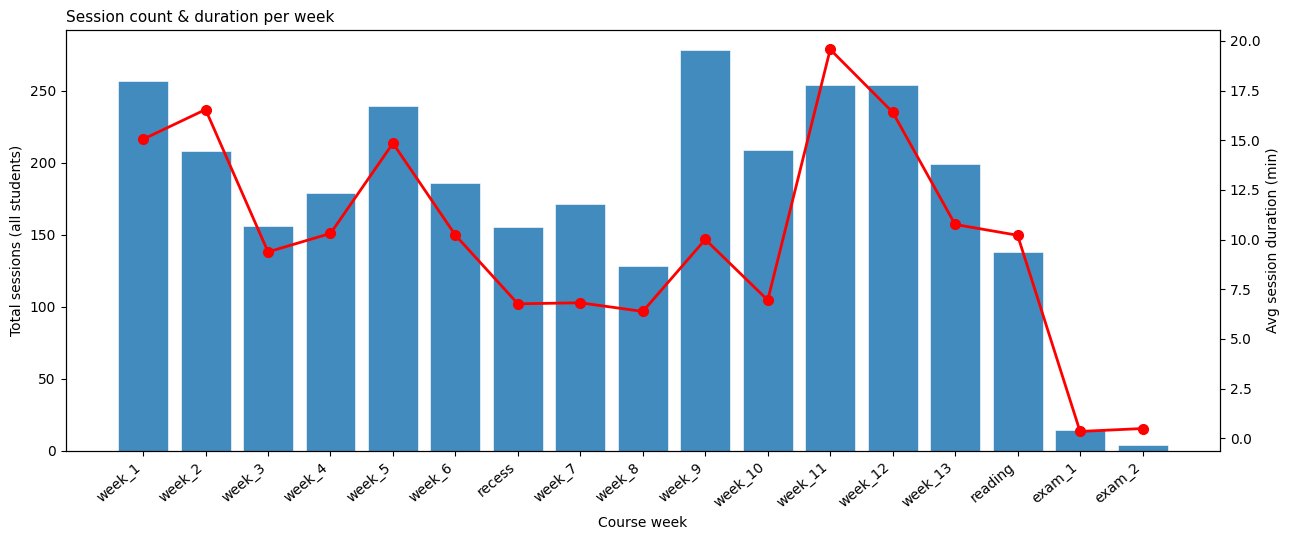

In [320]:
## Group by activity across all students --> totals for each week
week_totals = (
    weekly_activity
    .groupby('course_week', observed=True)
    .agg(
        total_sessions=('weekly_session_count', 'sum'),
        avg_duration=('avg_weekly_duration', 'mean'),
    )
    .reset_index()
)
week_totals = week_totals.sort_values('course_week').reset_index(drop=True)

## Convert duration from seconds to minutes
week_totals['avg_duration_min'] = week_totals['avg_duration'] / 60

fig, ax1 = plt.subplots(figsize=(13, 5.5))

## Bar chart for number of sessions
bars = ax1.bar(
    range(len(week_totals)),
    week_totals['total_sessions'],
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5,
)
ax1.set_xlabel('Course week')
ax1.set_ylabel('Total sessions (all students)')
ax1.set_xticks(range(len(week_totals)))
ax1.set_xticklabels(week_totals['course_week'], rotation=40, ha='right')

## Line for average total duration
ax2 = ax1.twinx()
ax2.plot(range(len(week_totals)), week_totals['avg_duration_min'],
         color='red', marker='o', linewidth=2, markersize=7, label='Avg duration')
ax2.set_ylabel('Avg session duration (min)')

plt.title('Session count & duration per week', fontsize=11, loc='left')
fig.tight_layout()
plt.show()